# EXPERIMENT NO. 7
## Motion Estimation using Optical Flow Algorithms in Video Sequences

**Name:** Abhigyan Dubey

**CUID:** CU24250059

**Course:** B.Tech CSE

**Section:** CSE "B"

**Roll No.:** 02

**Aim:** To implement Lucas-Kanade (sparse) and Farneback (dense) optical flow for estimating motion between consecutive video frames and analyze motion patterns using Python and OpenCV.

### Step 1: Import libraries and load video

In [3]:
import cv2, time
import numpy as np
import matplotlib.pyplot as plt

try:                                   # Google Colab: upload from computer
    from google.colab import files
    up = files.upload()
    video_filename = next(iter(up))
except ImportError:                    # Local Jupyter / VS Code: set path here
    video_filename = "video.mp4"
print("Using video:", video_filename)

Saving Y2meta.app-Genshin Impact - Zhongli [ Live Wallpaper ]-(1080p).mp4 to Y2meta.app-Genshin Impact - Zhongli [ Live Wallpaper ]-(1080p).mp4
Using video: Y2meta.app-Genshin Impact - Zhongli [ Live Wallpaper ]-(1080p).mp4


### Step 2: Read consecutive frames and convert to grayscale
Frames are downscaled (4K video can crash Colab) and the first few frames are skipped.

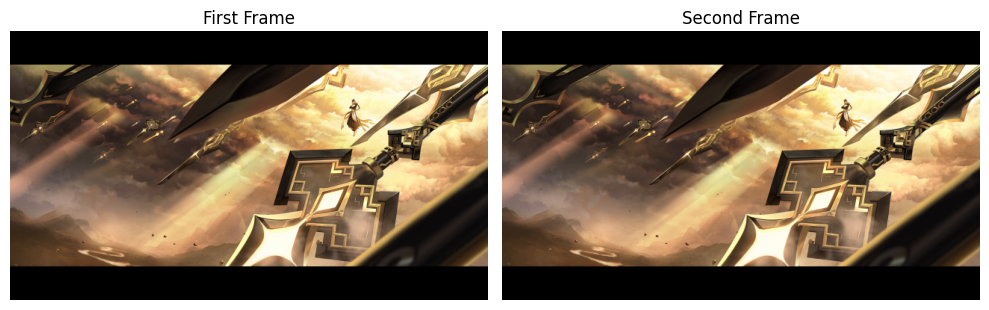

In [4]:
cap = cv2.VideoCapture(video_filename)
if not cap.isOpened():
    raise RuntimeError("Could not open video file.")
for _ in range(5): cap.read()                      # skip fade-in frames
frames = []
while len(frames) < 12:                            # keep 12 frames (needed for speed test)
    ok, f = cap.read()
    if not ok: break
    frames.append(f)
cap.release()
if len(frames) < 12:
    raise RuntimeError("Video too short (need at least 17 frames).")

W = 640
def small(f):
    h, w = f.shape[:2]
    return cv2.resize(f, (W, int(h*W/w)), interpolation=cv2.INTER_AREA) if w > W else f
frames = [small(f) for f in frames]
gray = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in frames]
frame1, frame2, gray1, gray2 = frames[0], frames[1], gray[0], gray[1]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, f, t in zip(ax, (frame1, frame2), ("First Frame", "Second Frame")):
    a.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

### Steps 3-6: Lucas-Kanade (sparse) and Farneback (dense) optical flow
Both are wrapped in functions so they can be reused for the analysis in Step 8.

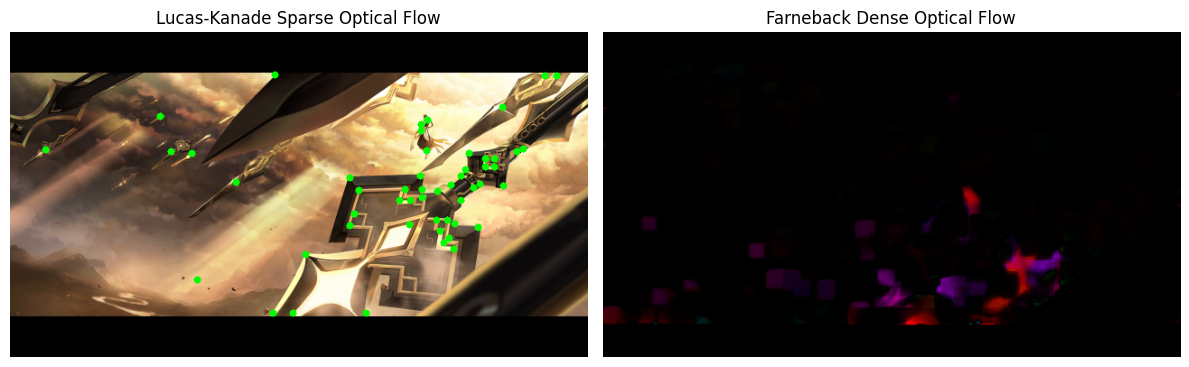

In [5]:
def lucas_kanade(g1, g2):
    p0 = cv2.goodFeaturesToTrack(g1, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
    if p0 is None: return np.empty((0, 2)), np.empty((0, 2))
    p1, st, _ = cv2.calcOpticalFlowPyrLK(g1, g2, p0, None, winSize=(15, 15), maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
    return p0[st == 1], p1[st == 1]            # successfully tracked points

def farneback(g1, g2):
    return cv2.calcOpticalFlowFarneback(g1, g2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

# ---- Lucas-Kanade: draw motion arrows ----
old, new = lucas_kanade(gray1, gray2)
lk_img = frame2.copy()
for (xo, yo), (xn, yn) in zip(old, new):
    cv2.arrowedLine(lk_img, (int(xo), int(yo)), (int(xn), int(yn)), (255, 0, 0), 2, tipLength=0.3)
    cv2.circle(lk_img, (int(xn), int(yn)), 4, (0, 255, 0), -1)

# ---- Farneback: colour-coded flow (hue = direction, brightness = magnitude) ----
flow = farneback(gray1, gray2)
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv = np.zeros_like(frame1)
hsv[..., 0] = ang * 180 / np.pi / 2
hsv[..., 1] = 255
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
fb_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# ---- Step 7: side-by-side comparison ----
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(lk_img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Lucas-Kanade Sparse Optical Flow")
ax[1].imshow(cv2.cvtColor(fb_img, cv2.COLOR_BGR2RGB)); ax[1].set_title("Farneback Dense Optical Flow")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

### Steps 7-8: Performance comparison and effect of speed, lighting and camera motion
Each scenario is compared with the same two algorithms. Metrics: run time (complexity), number of tracked points (coverage) and mean motion magnitude in pixels.

In [6]:
def evaluate(g1, g2):
    t = time.perf_counter(); o, n = lucas_kanade(g1, g2); t_lk = (time.perf_counter() - t) * 1000
    t = time.perf_counter(); fl = farneback(g1, g2);     t_fb = (time.perf_counter() - t) * 1000
    m_lk = np.linalg.norm(n - o, axis=1).mean() if len(o) else 0
    m_fb = np.linalg.norm(fl, axis=2).mean()
    return len(o), t_lk, m_lk, t_fb, m_fb

shift = np.float32([[1, 0, 8], [0, 1, 4]])                        # simulated camera pan
scenarios = {
    "Normal (frame 0 -> 1)":         (gray[0], gray[1]),
    "Fast motion (frame 0 -> 10)":   (gray[0], gray[10]),
    "Lighting change (dimmed)":      (gray[0], cv2.convertScaleAbs(gray[1], alpha=0.5, beta=0)),
    "Camera motion (8,4 px shift)":  (gray[0], cv2.warpAffine(gray[1], shift, gray[1].shape[::-1])),
}
print(f"{'Scenario':32s}{'LK pts':>7s}{'LK ms':>8s}{'LK mag':>8s}{'FB ms':>9s}{'FB mag':>8s}")
for name, (a, b) in scenarios.items():
    n, tl, ml, tf, mf = evaluate(a, b)
    print(f"{name:32s}{n:7d}{tl:8.1f}{ml:8.2f}{tf:9.1f}{mf:8.2f}")

Scenario                         LK pts   LK ms  LK mag    FB ms  FB mag
Normal (frame 0 -> 1)                52     5.7    0.03     85.2    0.09
Fast motion (frame 0 -> 10)          52     4.9    1.01     85.3    0.42
Lighting change (dimmed)             52     5.6   31.71     89.9    1.86
Camera motion (8,4 px shift)         52     4.9    8.95     84.8    6.13


### Step 9-10: Observations and Conclusion

**Comparison:** Lucas-Kanade is much faster because it tracks only about 100 corner points, but it gives motion only at those points. Farneback estimates motion at every pixel, so it is slower but gives a complete motion field (useful for segmenting moving objects).

**Effect of conditions (see table above):**
- *Object speed:* with larger frame gaps the motion is no longer small, so the assumption breaks down and Lucas-Kanade loses points or gives wrong vectors; Farneback's pyramid handles moderate motion better.
- *Lighting:* a brightness change violates brightness constancy, so tracked-point counts and flow accuracy drop.
- *Camera motion:* the whole image appears to move, so background points show motion and moving objects can no longer be separated without compensation.

**Suitability:** Lucas-Kanade suits real-time object tracking and robotics (fast, few points). Farneback suits surveillance, motion segmentation and action recognition, where full-frame motion is needed. Autonomous navigation typically uses both ideas with more robust (often deep-learning) variants.

**Conclusion:** Optical flow gives a reliable way to understand dynamic scenes, but its accuracy depends on small motion, stable lighting and textured surfaces.

## Viva Questions

**Q1. What is Optical Flow? How is it used?** Optical flow is the apparent motion of pixels between consecutive frames. It is used for object tracking, surveillance, autonomous navigation, motion analysis and action recognition.

**Q2. Principle of Lucas-Kanade?** It estimates the motion of selected feature points, assuming brightness stays constant and all pixels in a small window move together. It solves the optical flow equation over that window by least squares.

**Q3. Dense vs Sparse optical flow?** Sparse flow computes motion only at selected feature points (faster). Dense flow computes motion for almost every pixel (more complete but slower).

**Q4. Compare Lucas-Kanade and Farneback.** Lucas-Kanade is sparse, simple and fast, and works best on corners with small motion. Farneback is dense, based on polynomial expansion, gives full-frame motion but costs more computation.

**Q5. Assumptions?** (1) Brightness constancy, (2) small motion between frames, (3) spatial coherence: neighbouring pixels move similarly.

**Q6. Factors affecting accuracy?** Lighting changes, camera movement, object speed, noise, motion blur, occlusion, low texture and low frame rate.

**Q7. Five applications.** Autonomous driving, video surveillance, object tracking, human action recognition, motion detection and analysis.

**Q8. Why grayscale?** Intensity alone is enough for computing gradients, and one channel instead of three reduces computation.

**Q9. Limitations?** Sensitive to lighting changes, fails for large motion, occlusion and motion blur, struggles in textureless regions (aperture problem) and is affected by camera motion.

**Q10. Contribution to driving, surveillance, action recognition?** In driving it estimates the movement of vehicles and pedestrians; in surveillance it detects and tracks moving objects; in action recognition motion patterns identify human activities.

## Result
Lucas-Kanade sparse and Farneback dense optical flow were implemented using Python and OpenCV. Motion was visualized with arrows and colour-coded flow, and the two methods were compared on speed, lighting and camera motion.